# Machine Learning for Flood Forecasting in Central Vietnam

This notebook demonstrates a complete workflow for building a machine learning model to forecast river water levels and streamflow in Central Vietnam, using the CAMELS dataset and local data.

## Project Overview

Central Vietnam is highly vulnerable to severe flooding due to its dense river network, climate variability, deforestation, and rapid urbanization. This project aims to develop a machine learning model to forecast water levels in the Long Dai River (Quang Tri Province), supporting early warning and risk mitigation efforts.

- **Dataset:** CAMELS (Catchment Attributes and Meteorology for Large-sample Studies) and local Vietnamese data
- **Goal:** Predict river water levels and streamflow for flood risk management
- **Approach:** Transfer learning from similar US basins to the Long Dai River using machine learning

---


## Table of Contents
1. [Introduction](#introduction)
2. [Data Exploration](#data-exploration)
3. [Data Preparation](#data-preparation)
4. [Feature Engineering](#feature-engineering)
5. [Model Building](#model-building)
6. [Model Training & Evaluation](#model-training-evaluation)
7. [Application to Local Data](#application-local)
8. [Conclusion](#conclusion)


## Introduction

Floods are a major hazard in Central Vietnam, causing significant damage to agriculture, infrastructure, and human life. Accurate flood forecasting is essential for early warning and disaster risk reduction. This notebook presents a data-driven approach using machine learning to predict river water levels and streamflow.

In [ ]:
from google.colab import drive
drive.mount('/content/drive/')

Drive already mounted at /content/drive/; to attempt to forcibly remount, call drive.mount("/content/drive/", force_remount=True).


In [ ]:
#Đường dẫn tới dữ liệu
data_path = '/content/drive/MyDrive/data'

## Data Exploration

### Why CAMELS?
- CAMELS is a widely used benchmark dataset for hydrology and machine learning research.
- Contains static basin attributes (topography, climate, soil, geology, land cover) and daily time series (precipitation, temperature, streamflow, etc.) for nearly 700 US basins.
- Enables transfer learning to regions with limited data, such as Vietnam.

### Dataset Structure
- **Basin attributes:** elevation, slope, area, precipitation, PET, aridity, land cover, soil properties, geology, streamflow statistics
- **Time series:** daily meteorological forcings and observed streamflow


### Required Python Libraries

Install the following libraries if not already available:
- `cartopy` for geospatial mapping
- `folium` for interactive maps
- `python-ternary` for ternary plots

```bash
pip install cartopy folium python-ternary
```


In [ ]:
!pip install cartopy
!pip install folium
!pip install python-ternary

shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
The folder you are executing pip from can no longer be found.
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
The folder you are executing pip from can no longer be found.
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
shell-init: error retrieving current directory: getcwd: cannot access parent directories: No such file or directory
The folder you are executing pip from can no longer be found.


In [ ]:
# Import required libraries
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import numpy as np
import glob
from datetime import datetime, timedelta
import logging

## Data Preparation

Load and merge static basin attributes and time series data.

### Read and Analyze Data

Load the recommended columns for Vietnam analysis and merge all relevant data sources.

In [ ]:
%cd "/content/drive/MyDrive/data"

# Define recommended columns for Vietnam analysis (Chọn các đặc trưng tiêu biểu, sử dụng để lọc ra các gauges phù hợp với khí hậu và sông ngòi Việt Nam)
recommended_cols = {
    "name": ["gauge_id", "gauge_name"],
    "clim": ["gauge_id", "p_mean", "pet_mean", "aridity", "p_seasonality"],
    "topo": ["gauge_id", "gauge_lon", "gauge_lat", "elev_mean", "slope_mean", "area_gages2"],
    "soil": ["gauge_id", "soil_depth_statsgo", "sand_frac", "silt_frac", "clay_frac",
             "soil_porosity", "soil_conductivity"],
    "geol": ["gauge_id", "geol_1st_class", "geol_porostiy", "geol_permeability"],
    "vege": ["gauge_id", "frac_forest", "dom_land_cover", "lai_max", "gvf_max", "gvf_diff"]
}


# Load data
name_df = pd.read_csv('camels_name.txt', sep=';')[recommended_cols["name"]]
clim_df = pd.read_csv('camels_clim.txt', sep=';')[recommended_cols["clim"]]
topo_df = pd.read_csv('camels_topo.txt', sep=';')[recommended_cols["topo"]]
soil_df = pd.read_csv('camels_soil.txt', sep=';')[recommended_cols["soil"]]
geol_df = pd.read_csv('camels_geol.txt', sep=';')[recommended_cols["geol"]]
vege_df = pd.read_csv('camels_vege.txt', sep=';')[recommended_cols["vege"]]

print(f"Name data shape: {name_df.shape}")
print(f"Climate data shape: {clim_df.shape}")
print(f"Topography data shape: {topo_df.shape}")
print(f"Soil data shape: {soil_df.shape}")
print(f"Geological data shape: {geol_df.shape}")
print(f"Vegetation data shape: {vege_df.shape}")

# Merge all data
df = (name_df.merge(clim_df, on='gauge_id')
             .merge(topo_df, on='gauge_id')
             .merge(soil_df, on='gauge_id')
             .merge(geol_df, on='gauge_id')
             .merge(vege_df, on='gauge_id'))
print(f"Merged data shape: {df.shape}")

print("\nCLIMATE ATTRIBUTES:")
for col in recommended_cols["clim"][1:]:  # Skip gauge_id
    if col in df.columns:
        stats = df[col].describe()
        print(f"  {col}: min={stats['min']:.3f}, mean={stats['mean']:.3f}, max={stats['max']:.3f}")

print("\nTOPOGRAPHY ATTRIBUTES:")
for col in recommended_cols["topo"][1:]:
    if col in df.columns:
        stats = df[col].describe()
        print(f"  {col}: min={stats['min']:.3f}, mean={stats['mean']:.3f}, max={stats['max']:.3f}")

print("\nSOIL ATTRIBUTES:")
for col in recommended_cols["soil"][1:]:
    if col in df.columns:
        stats = df[col].describe()
        print(f"  {col}: min={stats['min']:.3f}, mean={stats['mean']:.3f}, max={stats['max']:.3f}")

print("\nVEGETATION ATTRIBUTES:")
for col in recommended_cols["vege"][1:]:
    if col in df.columns and pd.api.types.is_numeric_dtype(df[col]):
        stats = df[col].describe()
        print(f"  {col}: min={stats['min']:.3f}, mean={stats['mean']:.3f}, max={stats['max']:.3f}")

print("\nGEOLOGICAL ATTRIBUTES:")
for col in recommended_cols["geol"][1:]:
    if col in df.columns:
        if pd.api.types.is_numeric_dtype(df[col]):
            stats = df[col].describe()
            print(f"  {col}: min={stats['min']:.3f}, mean={stats['mean']:.3f}, max={stats['max']:.3f}")
        else:
            unique_vals = df[col].value_counts().head(5)
            print(f"  {col}: Top 5 types = {list(unique_vals.index)}")


/content/drive/.shortcut-targets-by-id/15F6cHv0-wiGTve_SGYHWeJWndCstZUzY/data
Name data shape: (671, 2)
Climate data shape: (671, 5)
Topography data shape: (671, 6)
Soil data shape: (671, 7)
Geological data shape: (671, 4)
Vegetation data shape: (671, 6)
Merged data shape: (671, 25)

CLIMATE ATTRIBUTES:
  p_mean: min=0.645, mean=3.258, max=8.937
  pet_mean: min=1.899, mean=2.787, max=4.744
  aridity: min=0.220, mean=1.057, max=5.208
  p_seasonality: min=-1.435, mean=-0.041, max=0.922

TOPOGRAPHY ATTRIBUTES:
  gauge_lon: min=-124.393, mean=-95.790, max=-67.935
  gauge_lat: min=27.052, mean=39.245, max=48.823
  elev_mean: min=10.210, mean=759.422, max=3571.180
  slope_mean: min=0.822, mean=46.195, max=255.688
  area_gages2: min=4.030, mean=792.618, max=25791.040

SOIL ATTRIBUTES:
  soil_depth_statsgo: min=0.400, mean=1.293, max=1.500
  sand_frac: min=8.184, mean=36.468, max=91.976
  silt_frac: min=2.985, mean=33.859, max=67.775
  clay_frac: min=1.846, mean=19.886, max=50.354
  soil_poros

### Visualize Gauge Locations

Plot the locations of all gauges in the CAMELS dataset on an interactive map.

In [ ]:
import folium

def plot_gauge_locations(df, lat_col='gauge_lat', lon_col='gauge_lon', popup_col='gauge_name', zoom_start=4):
    """
    Vẽ các vị trí trạm đo trên bản đồ tương tác sử dụng folium.

    Tham số:
    - df: DataFrame chứa dữ liệu vị trí trạm đo.
    - lat_col: Tên cột chứa giá trị vĩ độ.
    - lon_col: Tên cột chứa giá trị kinh độ.
    - popup_col: Cột sẽ được sử dụng làm chú thích khi bấm vào điểm (popup). Nếu là None, sẽ không hiển thị popup.
    - zoom_start: Mức độ thu phóng ban đầu của bản đồ.

    Trả về:
    - Đối tượng folium.Map.
    """
    if lat_col not in df.columns or lon_col not in df.columns:
        raise ValueError("Không tìm thấy cột vĩ độ hoặc kinh độ trong DataFrame.")

    lat_center = df[lat_col].mean()
    lon_center = df[lon_col].mean()

    # Khởi tạo bản đồ
    m = folium.Map(location=[lat_center, lon_center], zoom_start=zoom_start)

    # Thêm từng trạm đo vào bản đồ dưới dạng CircleMarker
    for _, row in df.iterrows():
        popup_text = f"{popup_col}: {row[popup_col]}" if popup_col and popup_col in row else None
        folium.CircleMarker(
            location=[row[lat_col], row[lon_col]],
            radius=5,
            color='red',
            fill=True,
            fill_opacity=0.7,
            popup=popup_text
        ).add_to(m)

    return m

In [ ]:
plot_gauge_locations(df)

## Vietnam Basin Characteristics (Reference)

- **Precipitation (p_mean):** 5.5 mm/day (~2007 mm/year)
- **Potential Evapotranspiration (pet_mean):** 4.0 mm/day
- **Aridity Index (aridity):** 0.62 (humid to sub-humid)
- **Rainfall Seasonality (p_seasonality):** 0.4 (distinct wet/dry seasons)
- **Latitude (gauge_lat):** 16.0°N (Central Vietnam)
- **Elevation (elev_mean):** 200 m
- **Slope (slope_mean):** 15°
- **Soil:** 35% sand, 25% silt, 35% clay, 50% porosity
- **Forest Cover (frac_forest):** 42%
- **Max LAI (lai_max):** 5.5
- **Max Green Vegetation Fraction (gvf_max):** 0.8


## Select Similar Basins

Filter CAMELS gauges to select those with climate and physiographic characteristics most similar to Central Vietnam.

### Compute Similarity Score

Calculate a similarity score for each gauge based on the reference characteristics above.

In [ ]:
print("Tính điểm tương đồng của các gauges dựa vào các đặc điểm khí hậu Việt Nam")
vietnam_ideal_updated = {
    # Climate
    'p_mean': 5.5,
    'pet_mean': 4.0,
    'aridity': 0.62,
    'p_seasonality': 0.4,

    # Topography
    'gauge_lat': 16.0,
    'elev_mean': 200.0,
    'slope_mean': 15.0,

    # Soil
    'sand_frac': 35.0,
    'silt_frac': 25.0,
    'clay_frac': 35.0,
    'soil_porosity': 0.5,

    # Vegetation (cập nhật theo thực tế VN 42%)
    'frac_forest': 0.42,
    'lai_max': 5.5,
    'gvf_max': 0.8,
}

def calculate_vietnam_similarity_updated(row):
    score = 0
    total_weight = 0

    # Trọng số ưu tiên (đảm bảo được tính quan trọng của mỗi yếu tố làm ảnh hưởng đến lưu lượng dòng chảy)
    weights = {
        # Climate
        'p_mean': 4.5,
        'pet_mean': 3.0,
        'aridity': 4.0,
        'p_seasonality': 3.5,

        # Topography
        'gauge_lat': 3.0,
        'elev_mean': 2.5,
        'slope_mean': 2.0,

        # Soil
        'sand_frac': 2.5,
        'silt_frac': 2.0,
        'clay_frac': 3.5,
        'soil_porosity': 2.0,

        # Vegetation
        'frac_forest': 4.5,
        'lai_max': 3.0,
        'gvf_max': 2.5,
    }

    for param, ideal_value in vietnam_ideal_updated.items():
        if param in row and not pd.isna(row[param]) and param in weights:
            # Tính normalized difference
            if param in ['p_mean', 'pet_mean', 'aridity', 'frac_forest', 'lai_max', 'gvf_max']:
                diff = abs(row[param] - ideal_value) / max(ideal_value, 0.1)
            elif param == 'p_seasonality':
                diff = abs(row[param] - ideal_value) / max(0.5, abs(ideal_value))
            elif param == 'gauge_lat':
                diff = abs(row[param] - ideal_value) / ideal_value
            elif param in ['elev_mean', 'slope_mean']:
                diff = abs(row[param] - ideal_value) / max(ideal_value, 50)
            elif param in ['sand_frac', 'silt_frac', 'clay_frac']:
                diff = abs(row[param] - ideal_value) / max(ideal_value, 10)
            elif param == 'soil_porosity':
                diff = abs(row[param] - ideal_value) / ideal_value

            # Convert to similarity (cải thiện hàm tương đồng)
            similarity = max(0, 1 - min(diff, 1.2))  # Cho phép sai lệch cao hơn một chút
            score += weights[param] * similarity
            total_weight += weights[param]

    return score / total_weight if total_weight > 0 else 0

# Tính điểm tương đồng cho tất cả trạm
df['vietnam_similarity_updated'] = df.apply(calculate_vietnam_similarity_updated, axis=1)

# Sắp xếp theo điểm tương đồng
df_sorted_updated = df.sort_values('vietnam_similarity_updated', ascending=False)

print("\nTOP 20 TRẠM TƯƠNG ĐỒNG CAO NHẤT:")
print("-" * 70)
display_cols_updated = ['gauge_id', 'gauge_name', 'gauge_lat', 'gauge_lon',
                       'p_mean', 'aridity', 'p_seasonality', 'elev_mean',
                       'frac_forest', 'clay_frac', 'vietnam_similarity_updated']
print(df_sorted_updated[display_cols_updated].head(20).to_string(index=False))




Tính điểm tương đồng của các gauges dựa vào các đặc điểm khí hậu Việt Nam

TOP 20 TRẠM TƯƠNG ĐỒNG CAO NHẤT:
----------------------------------------------------------------------
 gauge_id                                    gauge_name  gauge_lat  gauge_lon   p_mean  aridity  p_seasonality  elev_mean  frac_forest  clay_frac  vietnam_similarity_updated
  1638480             CATOCTIN CREEK AT TAYLORSTOWN, VA   39.25455  -77.57638 3.034423 0.843032       0.129989     155.98       0.4659  23.723315                    0.654730
  3357350              PLUM CREEK NEAR BAINBRIDGE, IND.   39.76171  -86.72945 3.220156 0.785652       0.192942     258.64       0.4476  25.530649                    0.645866
  2472000                     LEAF RIVER NR COLLINS, MS   31.70694  -89.40694 4.158402 0.761750      -0.163583     123.24       0.6696  29.054315                    0.644912
  1580000                       DEER CREEK AT ROCKS, MD   39.62997  -76.40331 3.431728 0.736437       0.084633     174.30    

### Export Similar Gauges

Export the list of high-similarity gauges to CSV for use in model training.

In [ ]:
# Phân loại các gauge dựa vào độ tương đồng
high_similarity_updated = df_sorted_updated[df_sorted_updated['vietnam_similarity_updated'] >= 0.6]
medium_similarity_updated = df_sorted_updated[(df_sorted_updated['vietnam_similarity_updated'] >= 0.5) &
                                             (df_sorted_updated['vietnam_similarity_updated'] < 0.6)]
print(f"\nPHÂN LOẠI THEO ĐIỂM TƯƠNG ĐỒNG:")
print("-" * 50)
print(f"Tương đồng cao (≥0.6): {len(high_similarity_updated)} trạm")
print(f"Tương đồng trung bình (0.5-0.6): {len(medium_similarity_updated)} trạm")
print("="*80)
print("EXPORTING RESULTS")
if len(high_similarity_updated) > 0:
    high_similarity_updated.to_csv('vietnam_similar_gauges_high.csv', index=False)
    print(f"  vietnam_similar_gauges_high.csv ({len(high_similarity_updated)} trạm)")

if len(medium_similarity_updated) > 0:
    medium_similarity_updated.to_csv('vietnam_similar_gauges_medium.csv', index=False)
    print(f"  vietnam_similar_gauges_medium.csv ({len(medium_similarity_updated)} trạm)")


PHÂN LOẠI THEO ĐIỂM TƯƠNG ĐỒNG:
--------------------------------------------------
Tương đồng cao (≥0.6): 30 trạm
Tương đồng trung bình (0.5-0.6): 269 trạm
EXPORTING RESULTS


OSError: [Errno 30] Read-only file system: 'vietnam_similar_gauges_high.csv'

In [ ]:
plot_gauge_locations(high_similarity_updated)

## Prepare Training Data

After selecting similar gauges, prepare the training dataset by merging meteorological forcings and observed streamflow for each gauge.

In [ ]:
def load_gauge_list(file_path):
    """Load ra gauge_ID có mức độ tương đồng cao"""
    df = pd.read_csv(file_path)
    gauge_ids = df['gauge_id'].astype(str).str.zfill(8).tolist()  # Ensure 8-digit format
    print(f"Loaded {len(gauge_ids)} gauge IDs")
    return gauge_ids

def find_gauge_files(gauge_id, base_path):
    """
    Dựa vào gauge_ID để tìm file chứa dữ liệu khí hậu hoặc môi trường được sử dụng làm đầu vào cho mô hình
    và dữ liệu dòng chảy (đầu ra mong muốn) đo đạt được
    """
    # Search in all HUC regions (01-18)
    for huc in [f"{i:02d}" for i in range(1, 19)]:
        # Check for forcing file
        forcing_file = f"{base_path}/basin_mean_forcing/daymet/{huc}/{gauge_id}_lump_cida_forcing_leap.txt"
        streamflow_file = f"{base_path}/usgs_streamflow/{huc}/{gauge_id}_streamflow_qc.txt"

        if os.path.exists(forcing_file) and os.path.exists(streamflow_file):
            return forcing_file, streamflow_file, huc

    return None, None, None

def read_forcing_data(file_path, start_year=1980, end_year=2014):
    """Đọc file chứa dữ liệu về khí hậu, môi trường"""
    try:
        with open(file_path, 'r') as f:
            lines = f.readlines()

        # 3 dòng đầu của file .txt có chứa metadata về vĩ độ, độ cao và diện tích khu vực khảo sát  (first 3 lines)
        metadata = {
            'latitude': float(lines[0].strip()),
            'elevation': float(lines[1].strip()),
            'area': float(lines[2].strip())
        }

        data_lines = lines[4:]
        data = []
        for line in data_lines:
            parts = line.strip().split()
            if len(parts) >= 10:
                year = int(parts[0])
                if start_year <= year <= end_year:
                    data.append({
                        'year': year,
                        'month': int(parts[1]),
                        'day': int(parts[2]),
                        'hour': int(parts[3]),
                        'dayl': float(parts[4]),      # day length (s)
                        'prcp': float(parts[5]),      # precipitation (mm/day)
                        'srad': float(parts[6]),      # solar radiation (W/m2)
                        'swe': float(parts[7]),       # snow water equivalent (mm)
                        'tmax': float(parts[8]),      # max temperature (C)
                        'tmin': float(parts[9]),      # min temperature (C)
                        'vp': float(parts[10])        # vapor pressure (Pa)
                    })

        df = pd.DataFrame(data)
        if not df.empty:
            df['date'] = pd.to_datetime(df[['year', 'month', 'day']])

        return df, metadata

    except Exception as e:
        print(f"Error reading forcing data from {file_path}: {e}")
        return None, None

def read_streamflow_data(file_path, start_year=1980, end_year=2014):
    """Đọc file chứa dữ liệu dòng chảy"""
    try:
        data = []
        with open(file_path, 'r') as f:
            for line in f:
                parts = line.strip().split()
                if len(parts) >= 5:
                    gauge_id = parts[0]
                    year = int(parts[1])
                    month = int(parts[2])
                    day = int(parts[3])
                    flow = float(parts[4])
                    quality = parts[5] if len(parts) > 5 else 'A'

                    if start_year <= year <= end_year:
                        data.append({
                            'gauge_id': gauge_id,
                            'year': year,
                            'month': month,
                            'day': day,
                            'streamflow': flow,
                            'quality': quality
                        })

        df = pd.DataFrame(data)
        if not df.empty:
            df['date'] = pd.to_datetime(df[['year', 'month', 'day']])
            # Filter only high quality data
            df = df[df['quality'].isin(['A', 'A:e'])]  # Approved data

        return df

    except Exception as e:
        print(f"Error reading streamflow data from {file_path}: {e}")
        return None

def process_gauge_data(gauge_id, base_path, start_year=1980, end_year=2014):
    """Merge dữ liệu metforcing và streamflow"""
    print(f"Processing gauge {gauge_id}")

    # Find files
    forcing_file, streamflow_file, huc = find_gauge_files(gauge_id, base_path)

    if not forcing_file or not streamflow_file:
        print(f"Files not found for gauge {gauge_id}")
        return None

    print(f"Found files for gauge {gauge_id} in HUC {huc}")

    # Read data
    forcing_df, metadata = read_forcing_data(forcing_file, start_year, end_year)
    streamflow_df = read_streamflow_data(streamflow_file, start_year, end_year)

    if forcing_df is None or streamflow_df is None:
        print(f"Failed to read data for gauge {gauge_id}")
        return None

    if forcing_df.empty or streamflow_df.empty:
        print(f"Empty data for gauge {gauge_id}")
        return None

    # Merge forcing and streamflow data on date
    merged_df = pd.merge(forcing_df, streamflow_df, on='date', how='inner')

    if merged_df.empty:
        print(f"No matching dates for gauge {gauge_id}")
        return None

    # Add gauge info
    merged_df['gauge_id'] = gauge_id
    merged_df['huc'] = huc

    # Add metadata
    for key, value in metadata.items():
        merged_df[f'basin_{key}'] = value

    print(f"Successfully processed {len(merged_df)} records for gauge {gauge_id}")
    return merged_df

def create_training_dataset(gauge_list_file, base_path, output_file, start_year=1980, end_year=2014):
    """Create complete training dataset for all gauges"""
    print(f"Creating training dataset for period {start_year}-{end_year}")

    # Load gauge list
    gauge_ids = load_gauge_list(gauge_list_file)

    all_data = []
    successful_gauges = []
    failed_gauges = []

    for i, gauge_id in enumerate(gauge_ids, 1):
        print(f"Processing gauge {i}/{len(gauge_ids)}: {gauge_id}")

        gauge_data = process_gauge_data(gauge_id, base_path, start_year, end_year)

        if gauge_data is not None:
            all_data.append(gauge_data)
            successful_gauges.append(gauge_id)
            print(f"✓ Gauge {gauge_id}: {len(gauge_data)} records")
        else:
            failed_gauges.append(gauge_id)
            print(f"✗ Failed to process gauge {gauge_id}")

    if not all_data:
        print("No data was successfully processed!")
        return None

    # Combine all data
    print("Combining all gauge data...")
    final_df = pd.concat(all_data, ignore_index=True)

    # Sort by gauge_id and date
    final_df = final_df.sort_values(['gauge_id', 'date']).reset_index(drop=True)

    # Reorder columns for better readability
    column_order = [
        'gauge_id', 'huc', 'date', 'year_x', 'month_x', 'day_x',
        'basin_latitude', 'basin_elevation', 'basin_area',
        'dayl', 'prcp', 'srad', 'swe', 'tmax', 'tmin', 'vp',
        'streamflow', 'quality'
    ]

    # Only include columns that exist
    available_columns = [col for col in column_order if col in final_df.columns]
    other_columns = [col for col in final_df.columns if col not in available_columns]
    final_columns = available_columns + other_columns

    final_df = final_df[final_columns]

    # Save to CSV
    print(f"Saving dataset to {output_file}")
    final_df.to_csv(output_file, index=False)

    # Print summary
    print("=" * 60)
    print("DATASET CREATION SUMMARY")
    print("=" * 60)
    print(f"Total gauges requested: {len(gauge_ids)}")
    print(f"Successfully processed: {len(successful_gauges)}")
    print(f"Failed to process: {len(failed_gauges)}")
    print(f"Success rate: {len(successful_gauges)/len(gauge_ids)*100:.1f}%")
    print(f"Total records: {len(final_df):,}")
    print(f"Date range: {final_df['date'].min()} to {final_df['date'].max()}")
    print(f"Average records per gauge: {len(final_df)/len(successful_gauges):.0f}")

    if failed_gauges:
        print(f"\nFailed gauges: {failed_gauges}")

    print(f"\nDataset saved to: {output_file}")
    print(f"File size: {os.path.getsize(output_file)/1024/1024:.1f} MB")

    return final_df

if __name__ == "__main__":
    # Configuration
    GAUGE_LIST_FILE = "/content/drive/MyDrive/data/vietnam_similar_gauges_high.csv"
    BASE_PATH = "/content/drive/MyDrive/data/basin_timeseries_v1p2_metForcing_obsFlow/basin_dataset_public_v1p2"
    OUTPUT_FILE = "vietnam_training_dataset_1980_2014.csv"
    START_YEAR = 1980
    END_YEAR = 2014

    # Create dataset
    dataset = create_training_dataset(
        gauge_list_file=GAUGE_LIST_FILE,
        base_path=BASE_PATH,
        output_file=OUTPUT_FILE,
        start_year=START_YEAR,
        end_year=END_YEAR
    )

    if dataset is not None:
        print("Training dataset created successfully!")

        # Display sample data
        print("\nSample data (first 5 rows):")
        print(dataset.head())

        print(f"\nDataset shape: {dataset.shape}")
        print(f"Columns: {list(dataset.columns)}")
    else:
        print("Failed to create training dataset!")

Creating training dataset for period 1980-2014


NameError: name 'pd' is not defined

In [ ]:
import numpy as np
import pandas as pd
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import ModelCheckpoint
from tensorflow.keras.optimizers import AdamW


# 1. Read the CSV into a DataFrame
df = pd.read_csv('vietnam_training_dataset_1980_2014.csv')

# 2. Define your feature columns and target column
features = ['dayl', 'prcp', 'srad', 'tmax', 'tmin', 'vp', 'streamflow']
target  = ['streamflow']

data = df[features + target].astype('float32')

# 3. Scale to [0,1]
scaler_X = RobustScaler()
scaler_y = RobustScaler()
X_all = scaler_X.fit_transform(data[features])
y_all = scaler_y.fit_transform(data[target])

print(X_all[:5])
print(y_all[:5])

## Model Building

Define and train an LSTM-based deep learning model for streamflow prediction.

Epoch 1/50
3696/3697 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 9.6875 - mae: 1.1088
Epoch 1: saving model to best_flood_model.h5


3697/3697 ━━━━━━━━━━━━━━━━━━━━ 136s 33ms/step - loss: 9.6876 - mae: 1.1088 - val_loss: 27.9548 - val_mae: 1.0530 - learning_rate: 0.0010
Epoch 2/50
3696/3697 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 8.9870 - mae: 1.0203
Epoch 2: saving model to best_flood_model.h5


3697/3697 ━━━━━━━━━━━━━━━━━━━━ 140s 34ms/step - loss: 8.9870 - mae: 1.0203 - val_loss: 32.7307 - val_mae: 1.0112 - learning_rate: 0.0010
2311/2311 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step


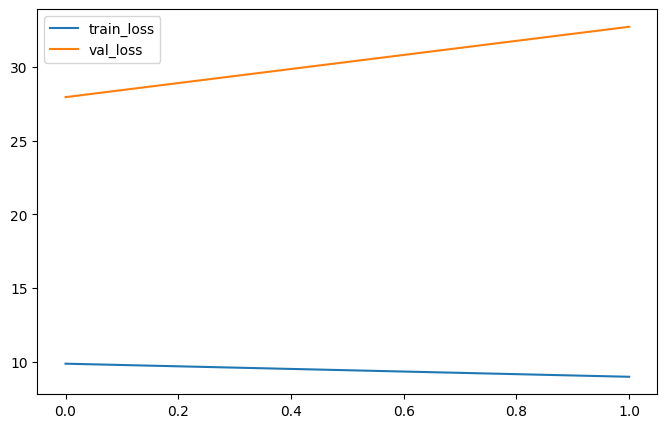

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import warnings
warnings.filterwarnings('ignore')

class FloodLSTMModel:
    def __init__(self, sequence_length=2, prediction_horizon=1):
        """
        LSTM Model cho dự đoán lũ lụt (không dùng static features)

        Args:
            sequence_length (int): Số ngày dữ liệu quá khứ để dự đoán
            prediction_horizon (int): Số ngày dự đoán tương lai
        """
        self.sequence_length = sequence_length
        self.prediction_horizon = prediction_horizon
        self.model = None
        self.scaler_features = RobustScaler()
        self.scaler_target = RobustScaler()

        # Chỉ giữ ew_features
        self.feature_cols = ['dayl', 'prcp', 'srad', 'tmax', 'tmin', 'vp', 'streamflow']
        self.target_feature = 'streamflow'

    def load_and_explore_data(self, data_path):
        df = pd.read_csv(data_path, parse_dates=['date'])
        # ... (giữ nguyên code khám phá nếu cần) ...
        return df

    def engineer_features(self, df):
        df = df.copy().sort_values(['gauge_id', 'date']).reset_index(drop=True)
        # Tạo cyclical time features
        df['month'] = df['date'].dt.month
        df['day_of_year'] = df['date'].dt.dayofyear
        df['month_sin'] = np.sin(2 * np.pi * df['month'] / 12)
        df['month_cos'] = np.cos(2 * np.pi * df['month'] / 12)
        df['day_sin'] = np.sin(2 * np.pi * df['day_of_year'] / 365)
        df['day_cos'] = np.cos(2 * np.pi * df['day_of_year'] / 365)

        # Rolling precipitation
        for window in [3, 7, 15, 30]:
            df[f'prcp_rolling_{window}d'] = df.groupby('gauge_id')['prcp'].transform(
                lambda x: x.rolling(window, min_periods=1).sum())

        # Lag features cho streamflow
        for lag in [1, 2, 3, 7]:
            df[f'streamflow_lag_{lag}'] = df.groupby('gauge_id')['streamflow'].shift(lag)

        # Giữ lại ew_features + cyclical
        keep_cols = ['gauge_id', 'date'] + self.feature_cols + ['month_sin','month_cos','day_sin','day_cos'] + \
                    [c for c in df.columns if c.startswith('prcp_rolling_')] + \
                    [c for c in df.columns if c.startswith('streamflow_lag_')]
        df = df[keep_cols].dropna()
        return df

    def create_sequences(self, df):
        sequences_X, sequences_y = [], []
        for gauge_id, group in df.groupby('gauge_id'):
            data = group.sort_values('date')
            X_vals = data[self.feature_cols].values
            y_vals = data[self.target_feature].values
            for i in range(len(data) - self.sequence_length - self.prediction_horizon + 1):
                sequences_X.append(X_vals[i:i+self.sequence_length])
                sequences_y.append(y_vals[i+self.sequence_length:i+self.sequence_length+self.prediction_horizon])
        X = np.array(sequences_X)
        y = np.array(sequences_y)
        return X, y

    def build_model(self, input_shape, lstm_units=[128,64], dropout_rate=0.2):
        ts_input = Input(shape=input_shape, name='timeseries_input')
        x = ts_input
        for i, units in enumerate(lstm_units):
            return_seq = i < len(lstm_units)-1
            x = LSTM(units, return_sequences=return_seq,
                     dropout=dropout_rate, recurrent_dropout=dropout_rate,
                     name=f'lstm_{i+1}')(x)
            x = BatchNormalization(name=f'bn_lstm_{i+1}')(x)
        dense = Dense(64, activation='relu', name='dense_1')(x)
        dense = Dropout(dropout_rate, name='dropout_1')(dense)
        dense = BatchNormalization(name='bn_dense_1')(dense)
        dense = Dense(32, activation='relu', name='dense_2')(dense)
        dense = Dropout(dropout_rate, name='dropout_2')(dense)
        dense = BatchNormalization(name='bn_dense_2')(dense)
        output = Dense(self.prediction_horizon, activation='linear', name='output')(dense)
        model = Model(inputs=ts_input, outputs=output)
        model.compile(optimizer=Adam(0.001), loss='mse', metrics=['mae'])
        self.model = model
        return model

    def prepare_training_data(self, X, y, test_size=0.2, val_size=0.2):
        n_samples, n_timesteps, n_features = X.shape
        X_flat = X.reshape(-1, n_features)
        X_scaled = self.scaler_features.fit_transform(X_flat).reshape(n_samples, n_timesteps, n_features)
        y_scaled = self.scaler_target.fit_transform(y)
        split = int(n_samples*(1-test_size))
        X_train_full, X_test = X_scaled[:split], X_scaled[split:]
        y_train_full, y_test = y_scaled[:split], y_scaled[split:]
        val_idx = int(len(X_train_full)*(1-val_size))
        X_train, X_val = X_train_full[:val_idx], X_train_full[val_idx:]
        y_train, y_val = y_train_full[:val_idx], y_train_full[val_idx:]
        return (X_train, X_val, X_test), (y_train, y_val, y_test)

    def train_model(self, splits, epochs=50, batch_size=64):
        (X_train, X_val, X_test), (y_train, y_val, y_test) = splits
        callbacks = [EarlyStopping('val_loss',30,True), ReduceLROnPlateau('val_loss',0.5,8,1e-6),
                     ModelCheckpoint('best_flood_model.h5','val_loss',True)]
        history = self.model.fit(X_train, y_train, validation_data=(X_val,y_val),
                                  epochs=epochs, batch_size=batch_size, callbacks=callbacks)
        return history, (X_test, y_test)

    def evaluate_model(self, test_data):
        X_test, y_test = test_data
        pred_scaled = self.model.predict(X_test)
        y_pred = self.scaler_target.inverse_transform(pred_scaled)
        y_true = self.scaler_target.inverse_transform(y_test)
        mse = mean_squared_error(y_true.flatten(), y_pred.flatten())
        mae = mean_absolute_error(y_true.flatten(), y_pred.flatten())
        rmse = np.sqrt(mse)
        r2 = r2_score(y_true.flatten(), y_pred.flatten())
        return {'y_true': y_true, 'y_pred': y_pred, 'metrics': {'mse':mse,'mae':mae,'rmse':rmse,'r2':r2}}

    def plot_results(self, history, eval_res):
        plt.figure(figsize=(8,5))
        plt.plot(history.history['loss'], label='train_loss')
        plt.plot(history.history['val_loss'], label='val_loss')
        plt.legend(); plt.show()

if __name__ == '__main__':
    model = FloodLSTMModel(sequence_length=2, prediction_horizon=1)
    df = model.load_and_explore_data('/content/vietnam_training_dataset_1980_2014.csv')
    df_eng = model.engineer_features(df)
    X, y = model.create_sequences(df_eng)
    model.build_model(input_shape=(model.sequence_length, X.shape[2]))
    splits = model.prepare_training_data(X, y)
    history, test_data = model.train_model(splits)
    eval_res = model.evaluate_model(test_data)
    model.plot_results(history, eval_res)


## Application to Local Data (Long Dai River)

Apply the trained model to the Long Dai River using local attributes and meteorological data.

In [ ]:
# (Optional) Add code here to apply the trained model to new data or visualize results for the Long Dai River.